In [60]:
import pandas as pd 
import numpy as np 

In [61]:
data = pd.read_csv('U.S._Chronic_Disease_Indicators__CDI___2023_Release copy.csv', low_memory=False)

In [62]:
data.shape

(1185676, 34)

In [63]:
df1 = pd.read_csv('MEDICAID_AGGREGATE20.CSV')

In [64]:
conda install openpyxl

Retrieving notices: - \ done
Channels:
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [65]:
data.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DatavalueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'StratificationCategory3', 'Stratification3',
       'GeoLocation', 'ResponseID', 'LocationID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1',
       'StratificationCategoryID2', 'StratificationID2',
       'StratificationCategoryID3', 'StratificationID3'],
      dtype='object')

In [66]:
data['DataValueType'].value_counts()

Crude Prevalence                                                    370903
Age-adjusted Prevalence                                             282080
Number                                                              105407
Age-adjusted Rate                                                   102457
Crude Rate                                                          102457
Average Annual Number                                                53248
Average Annual Crude Rate                                            53248
Average Annual Age-adjusted Rate                                     53248
Mean                                                                 24145
Age-adjusted Mean                                                    23925
Median                                                                7200
Percent                                                               2741
Yes/No                                                                2102
US Dollars               

In [67]:
#select relevant columns only and rename them 
filtered_df = (
    data[
        (data['DataValueType'] == 'Number') & 
        (data['StratificationCategory1'].isin(['Gender', 'Race/Ethnicity']))
    ][['YearStart', 'LocationDesc', 'Topic', 'DataValue', 'StratificationCategory1', 'Stratification1']]
    .rename(columns={
        'YearStart': 'Year',
        'LocationDesc': 'State',
        'Topic': 'Disease',
        'DataValue': 'Number_Diagnosed'
    })
    .assign(
        Year=lambda df: pd.to_numeric(df['Year'], errors='coerce'),
        Number_Diagnosed=lambda df: pd.to_numeric(df['Number_Diagnosed'], errors='coerce')
    )
    .sort_values(by=['Year', 'State'])
)

In [68]:
data = filtered_df.copy()

In [69]:
data = data[data['Disease']=='Cardiovascular Disease']

In [70]:
data.isnull().sum()

Year                          0
State                         0
Disease                       0
Number_Diagnosed           6940
StratificationCategory1       0
Stratification1               0
dtype: int64

In [71]:
#remove rows with na in 'number_diagnosed'
data= data.dropna()

In [72]:
data.isnull().sum()

Year                       0
State                      0
Disease                    0
Number_Diagnosed           0
StratificationCategory1    0
Stratification1            0
dtype: int64

In [73]:
df1 = pd.read_csv('MEDICAID_AGGREGATE20.CSV')

In [74]:
df1=df1[['State_Name', 'Y2010','Y2011','Y2012','Y2013','Y2014','Y2015','Y2016','Y2017','Y2018','Y2019','Y2020']]

In [75]:
medicaid_df = df1.dropna()


In [76]:
medicaid_df.head()

,State_Name,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020
9,Alabama,5003,4426,4767,4671,4990,5044,4818,5189,5350,5649,5731
10,Alaska,1101,1230,1303,1267,1338,1456,1860,1959,2007,2127,1942
11,Arizona,7915,7171,7090,7340,8374,9022,9455,10356,10419,11464,12760
12,Arkansas,3732,3819,3924,4042,4957,5193,5709,5886,6191,6111,6116
13,California,41797,44669,50882,55223,60472,74700,77965,72559,73641,78339,87062


In [77]:
# reshape medicaid df to long format and group by state then sum all medicaid expenses
# 1. Melt the DataFrame (pivot_longer equivalent)
medicaid_long = pd.melt(medicaid_df, 
                        id_vars=['State_Name'], 
                        value_vars=[col for col in medicaid_df.columns if col.startswith('Y20')],
                        var_name='Year', 
                        value_name='Expenses')

# 2. Clean the 'Year' column by removing the 'Y' and converting to int
medicaid_long['Year'] = medicaid_long['Year'].str.replace('Y', '', regex=False).astype(int)

# 3. Group by State and Year, then sum Expenses
medicaid_grouped = medicaid_long.groupby(['State_Name', 'Year'], as_index=False).agg(
    Medicaid_Expenses=('Expenses', 'sum')
)

print(medicaid_grouped.head())

  State_Name  Year  Medicaid_Expenses
0    Alabama  2010              10007
1    Alabama  2011               8852
2    Alabama  2012               9533
3    Alabama  2013               9340
4    Alabama  2014               9979


In [78]:
combined_df = pd.merge(medicaid_grouped, data, how='left', left_on=['State_Name', 'Year'], right_on=['State', 'Year'])

# Display the first few rows of the combined DataFrame
print(combined_df.head())

  State_Name  Year  Medicaid_Expenses    State                 Disease  \
0    Alabama  2010              10007  Alabama  Cardiovascular Disease   
1    Alabama  2010              10007  Alabama  Cardiovascular Disease   
2    Alabama  2010              10007  Alabama  Cardiovascular Disease   
3    Alabama  2010              10007  Alabama  Cardiovascular Disease   
4    Alabama  2010              10007  Alabama  Cardiovascular Disease   

   Number_Diagnosed StratificationCategory1      Stratification1  
0              48.0          Race/Ethnicity             Hispanic  
1            3057.0                  Gender                 Male  
2            4414.0          Race/Ethnicity  White, non-Hispanic  
3            2500.0                  Gender               Female  
4           11925.0          Race/Ethnicity  White, non-Hispanic  


In [79]:
# select columns with data from 2010 through 2020
df2 = pd.read_excel('h08.xlsx', engine='openpyxl')

In [80]:
df2 = df2.iloc[6:, :]
df2.head()

,Table with row headers in column A and column headers in rows 8 through 9 and 63 through 64,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84
6,State,2023,NaN,2022,NaN,2021,NaN,2020 (41),NaN,2019,...,1988,NaN,1987 (21),NaN,1986,NaN,1985 (20),NaN,1984 (19),NaN
7,NaN,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,...,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error
8,United States,80610,385,74580,588,70780,368,68010,535,68700,...,27230,139,26060,127,24900,129,23620,128,22420,102
9,Alabama,60660,3993,59910,1934,56930,2294,54690,2563,56200,...,19950,912,19730,1147,19130,885,18330,760,17310,605
10,Alaska,98190,6112,89740,4842,81130,3967,74750,3557,78390,...,33100,1183,33230,1497,31360,1017,34780,1089,32360,1473


In [81]:
df2.columns = df2.iloc[0, :]
df2 = df2.iloc[1:, :]
df2.head()

6,State,2023,NaN,2022,NaN,2021,NaN,2020 (41),NaN,2019,...,1988,NaN,1987 (21),NaN,1986,NaN,1985 (20),NaN,1984 (19),NaN
7,NaN,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,...,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error,Median income,Standard error
8,United States,80610,385,74580,588,70780,368,68010,535,68700,...,27230,139,26060,127,24900,129,23620,128,22420,102
9,Alabama,60660,3993,59910,1934,56930,2294,54690,2563,56200,...,19950,912,19730,1147,19130,885,18330,760,17310,605
10,Alaska,98190,6112,89740,4842,81130,3967,74750,3557,78390,...,33100,1183,33230,1497,31360,1017,34780,1089,32360,1473
11,Arizona,82660,2723,73450,4123,70820,3394,67090,3409,70670,...,26440,843,26750,892,25500,718,23880,744,21430,609


In [82]:
df2= df2[['State', '2020 (41)', 2019,2018,'2017 (40)',2016, 2015,2014,'2013 (39)',2012,2011,'2010 (37)']]

In [83]:
df2.rename(columns ={'2020 (41)':'2020', '2017 (40)':'2017','2013 (39)':'2013','2010 (37)':'2010'}, inplace=True)

In [84]:
df2 = df2.drop(index=7)
df2.head()

6,State,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010
8,United States,68010,68700,63180,61140,59040,56520,53660,53590,51020,50050,49280
9,Alabama,54690,56200,49940,50870,47220,44510,42280,47320,43460,42590,40930
10,Alaska,74750,78390,68730,77990,75720,75110,67630,72470,63650,57430,57850
11,Arizona,67090,70670,62280,59700,57100,52250,49250,52610,47040,48620,46900
12,Arkansas,50780,54540,49780,49750,45910,42800,44920,39380,39020,41300,38590


In [85]:
df2=df2[~df2['State'].isin(['United States','District of Columbia','2023 Dollars','State'])]

In [86]:
df2.columns = [str(col) if isinstance(col, int) or (isinstance(col, str) and col.isdigit()) else col for col in df2.columns]


In [87]:
long_df2 = df2.melt(
    id_vars=[col for col in df2.columns if col not in [str(year) for year in range(2010, 2021)]],
    value_vars=[str(year) for year in range(2010, 2021)],
    var_name='Year',
    value_name='Median_Income'
)

In [88]:
long_df2.head()

,State,Year,Median_Income
0,Alabama,2010,40930
1,Alaska,2010,57850
2,Arizona,2010,46900
3,Arkansas,2010,38590
4,California,2010,54280


In [89]:
long_df2['Year'] = long_df2['Year'].astype(int)
long_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111 entries, 0 to 1110
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   State          1100 non-null   object
 1   Year           1111 non-null   int32 
 2   Median_Income  1111 non-null   object
dtypes: int32(1), object(2)
memory usage: 21.8+ KB


In [90]:
final_df = pd.merge(combined_df, long_df2, how='left', left_on=['State_Name', 'Year'], right_on=['State', 'Year'])

# Display the first few rows of the combined DataFrame
print(final_df.head())

  State_Name  Year  Medicaid_Expenses  State_x                 Disease  \
0    Alabama  2010              10007  Alabama  Cardiovascular Disease   
1    Alabama  2010              10007  Alabama  Cardiovascular Disease   
2    Alabama  2010              10007  Alabama  Cardiovascular Disease   
3    Alabama  2010              10007  Alabama  Cardiovascular Disease   
4    Alabama  2010              10007  Alabama  Cardiovascular Disease   

   Number_Diagnosed StratificationCategory1      Stratification1  State_y  \
0              48.0          Race/Ethnicity             Hispanic  Alabama   
1              48.0          Race/Ethnicity             Hispanic  Alabama   
2            3057.0                  Gender                 Male  Alabama   
3            3057.0                  Gender                 Male  Alabama   
4            4414.0          Race/Ethnicity  White, non-Hispanic  Alabama   

  Median_Income  
0         40930  
1         55440  
2         40930  
3         55440  
4 

In [91]:
final_df.drop(['State_x', 'State_y'], axis = 1,inplace=True)

In [92]:
final_df = final_df.dropna()

In [93]:
final_df.isnull().sum()

State_Name                 0
Year                       0
Medicaid_Expenses          0
Disease                    0
Number_Diagnosed           0
StratificationCategory1    0
Stratification1            0
Median_Income              0
dtype: int64

In [94]:
final_df['Median_Income'] = pd.to_numeric(final_df['Median_Income'], errors='coerce')

In [95]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41278 entries, 0 to 41620
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State_Name               41278 non-null  object 
 1   Year                     41278 non-null  int64  
 2   Medicaid_Expenses        41278 non-null  int64  
 3   Disease                  41278 non-null  object 
 4   Number_Diagnosed         41278 non-null  float64
 5   StratificationCategory1  41278 non-null  object 
 6   Stratification1          41278 non-null  object 
 7   Median_Income            41278 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 2.8+ MB


# Exploratory data analysis 

In [96]:
# summary stats for numeric columns
final_df.describe()

,Year,Medicaid_Expenses,Number_Diagnosed,Median_Income
count,41278.000000,41278.000000,41278.000000,41278.000000
mean,2015.043365,20726.821212,3511.611512,65354.266922
std,3.110503,26088.879321,6024.934518,13813.069137
min,2010.000000,1017.000000,20.000000,32340.000000
25%,2012.000000,6166.000000,148.000000,55250.000000
50%,2015.000000,14373.000000,1090.000000,64120.000000
75%,2018.000000,22306.000000,4265.750000,74180.000000
max,2020.000000,174123.000000,55112.000000,113000.000000


In [97]:
final_df.groupby('Stratification1', as_index=False)['Number_Diagnosed'].mean()

,Stratification1,Number_Diagnosed
0,American Indian or Alaska Native,105.441760
1,Asian or Pacific Islander,321.800571
2,"Black, non-Hispanic",1532.097845
3,Female,4900.913878
4,Hispanic,703.544493
5,Male,5121.142074
6,"White, non-Hispanic",7900.734237


In [98]:
# summary stats by state
final_df.groupby('State_Name')[['Medicaid_Expenses', 'Number_Diagnosed', 'Median_Income']].agg(['mean', 'median'])

Medicaid_Expenses           Number_Diagnosed          \
                            mean    median             mean  median   
State_Name                                                            
Alabama             10172.786325   10007.0      3470.925926  2726.0   
Alaska               3312.756983    3719.0       235.282123   170.0   
Arizona             18349.850000   18044.0      2680.278571   856.5   
Arkansas            10204.241135   10386.0      2254.217494  1375.0   
California         129042.323529  145118.0     13540.756303  7093.5   
Colorado            13471.324578   14356.0      1681.123827   587.0   
Connecticut         14395.565891   14786.0      1930.312661   767.0   
Delaware             3309.096774    3172.0       693.361290   515.0   
Florida             36335.529520   36522.0     11269.461255  6026.5   
Georgia             17694.300683   17562.0      4637.476082  3123.0   
Hawaii               3325.677922    3438.0       694.677922   571.0   
Idaho                3445.814035    3262.0       937.136842   740.0   
Illinois            32410.142857   31825.0      6532.554187  3929.5   
Indiana             18123.311224   17767.0      3745.844388  1501.0   
Iowa                 7863.452607    7995.0      2067.694313  1376.5   
Kansas               5340.983568    5101.0      1359.230047   336.0   
Kentucky            15039.154964   16123.0      3387.501211  2123.0   
Louisiana           16605.492462   15108.0      2686.238693  1780.5   
Maine                5011.366197    4864.0      1489.624413  1377.0   
Maryland            17815.695021   17555.0      2963.854772  1908.5   
Massachusetts       28554.986207   30292.0      3416.579310   930.0   
Michigan            26971.757246   28265.0      5786.471014  2457.0   
Minnesota           19761.217039   19518.0      2143.099391   244.0   
Mississippi          9147.195652    9373.0      2361.421196  2268.0   
Missouri            18156.594595   18441.0      3599.164619  1707.0   
Montana              2707.864662    2282.0       740.545113   604.5   
Nebraska             3626.304110    3535.0      1105.931507   814.0   
Nevada               5242.545966    5748.0      1236.707317   534.0   
New Hampshire        3118.849765    3015.0      1242.619718  1201.0   
New Jersey          24015.792757   25232.0      4881.724346  2493.0   
New Mexico           7957.880903    8905.0       881.383984   666.0   
New York           112344.629191  111828.0      9635.660750  4131.0   
North Carolina      23617.341682   22968.0      4703.112701  2453.0   
North Dakota         1935.174603    2094.0       564.615079   510.5   
Ohio                36436.178484   38912.0      7124.740831  3422.0   
Oklahoma             9240.865342    9292.0      2158.763797   735.0   
Oregon              13016.190563   14621.0      1706.854809   176.0   
Pennsylvania        45805.907960   44188.0      8362.656716  3628.0   
Rhode Island         4334.130982    4528.0       775.544081   573.0   
South Carolina      10540.582949   10908.0      2950.947005  2430.0   
South Dakota         1577.956113    1552.0       696.943574   657.0   
Tennessee           16348.896552   16056.0      4219.156499  2605.0   
Texas               61940.322940   65067.0      9877.209354  5863.0   
Utah                 4210.263959    3943.0       895.888325   473.0   
Vermont              2989.410256    3121.0       642.897436   581.5   
Virginia            15964.910412   14992.0      3682.365617  2465.0   
Washington          18840.000000   19534.0      2750.450000   499.0   
West Virginia        6401.037383    6674.0      2014.785047  1826.0   
Wisconsin           14863.535649   15015.0      2753.301645   533.0   
Wyoming              1106.086066    1110.0       392.868852   351.0   

               Median_Income           
                        mean   median  
State_Name                             
Alabama         53388.603989  55440.0  
Alaska          79162.206704  78340.0  
Arizona         62343.000000  62280.0  
Arkansas   

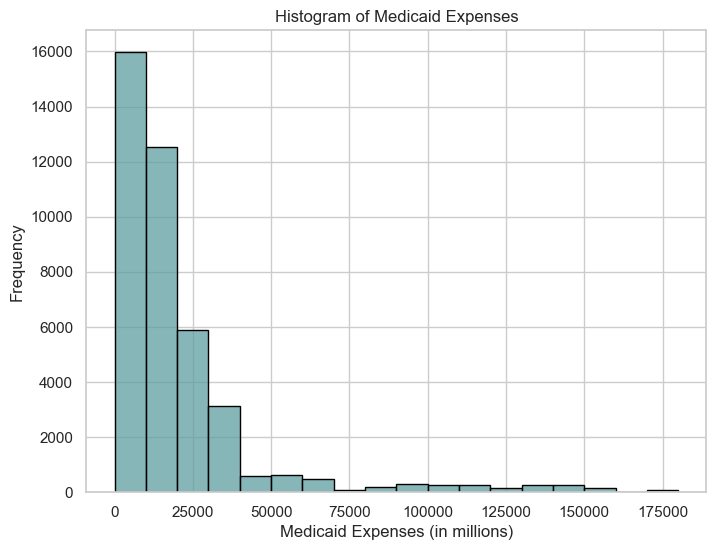

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn (optional)
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
sns.histplot(final_df['Medicaid_Expenses'], bins=range(0, int(final_df['Medicaid_Expenses'].max()) + 10000, 10000), 
             color="cadetblue", kde=False, edgecolor="black")

# Adding titles and labels
plt.title("Histogram of Medicaid Expenses")
plt.xlabel("Medicaid Expenses (in millions)")
plt.ylabel("Frequency")

# Show the plot
plt.show()

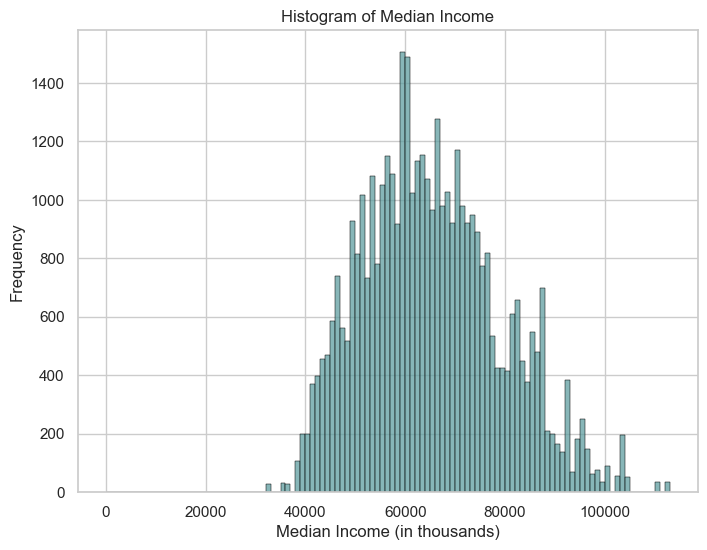

In [100]:
# Set the style for seaborn (optional)
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
sns.histplot(final_df['Median_Income'], bins=range(0, int(final_df['Median_Income'].max()) + 1000, 1000), 
             color="cadetblue", kde=False, edgecolor="black")

# Adding titles and labels
plt.title("Histogram of Median Income")
plt.xlabel("Median Income (in thousands)")
plt.ylabel("Frequency")

# Show the plot
plt.show()

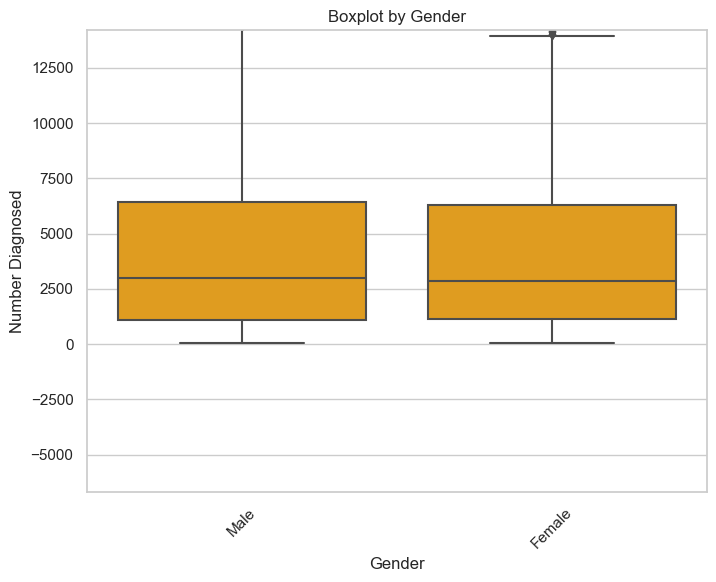

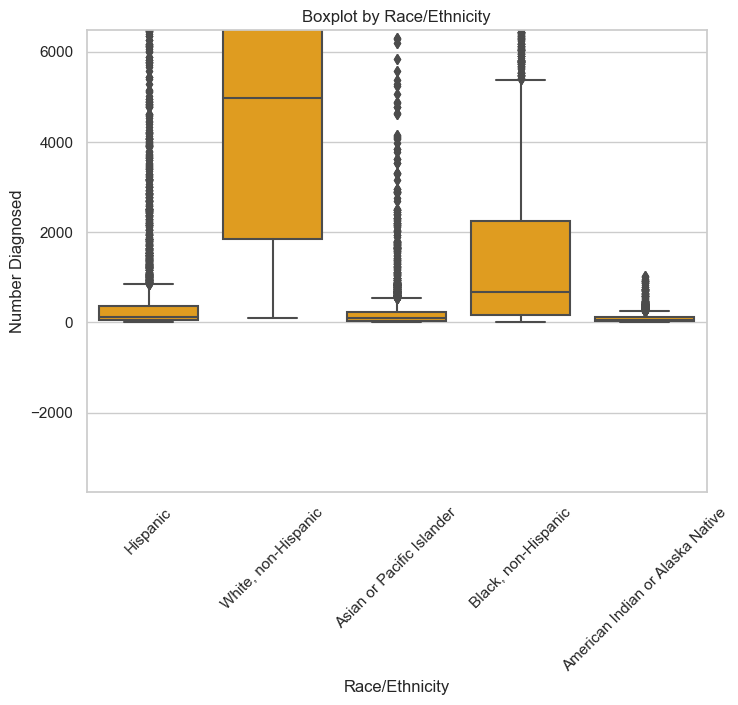

In [101]:
# Filter to gender
gender = final_df[final_df['StratificationCategory1'] == 'Gender']

# Filter to race/ethnicity
race = final_df[final_df['StratificationCategory1'] == 'Race/Ethnicity']

# Calculate the IQR (Interquartile Range) for both datasets
Q1_gender = gender['Number_Diagnosed'].quantile(0.25)
Q3_gender = gender['Number_Diagnosed'].quantile(0.75)
IQR_gender = Q3_gender - Q1_gender

Q1_race = race['Number_Diagnosed'].quantile(0.25)
Q3_race = race['Number_Diagnosed'].quantile(0.75)
IQR_race = Q3_race - Q1_race

# Set the style for seaborn (optional)
sns.set(style="whitegrid")

# Boxplot by gender with zoom on IQR (whis=1.5 by default, but we're explicitly focusing on IQR)
plt.figure(figsize=(8, 6))
sns.boxplot(data=gender, x='Stratification1', y='Number_Diagnosed', color="orange", whis=1.5)
plt.title("Boxplot by Gender")
plt.xlabel("Gender")
plt.ylabel("Number Diagnosed")
plt.xticks(rotation=45)  # Optional: Rotate labels if they are long
plt.ylim(Q1_gender - 1.5 * IQR_gender, Q3_gender + 1.5 * IQR_gender)  # Set y-axis limits based on IQR
plt.show()

# Boxplot by race/ethnicity with zoom on IQR
plt.figure(figsize=(8, 6))
sns.boxplot(data=race, x='Stratification1', y='Number_Diagnosed', color="orange", whis=1.5)
plt.title("Boxplot by Race/Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number Diagnosed")
plt.xticks(rotation=45)  # Optional: Rotate labels if they are long
plt.ylim(Q1_race - 1.5 * IQR_race, Q3_race + 1.5 * IQR_race)  # Set y-axis limits based on IQR
plt.show()

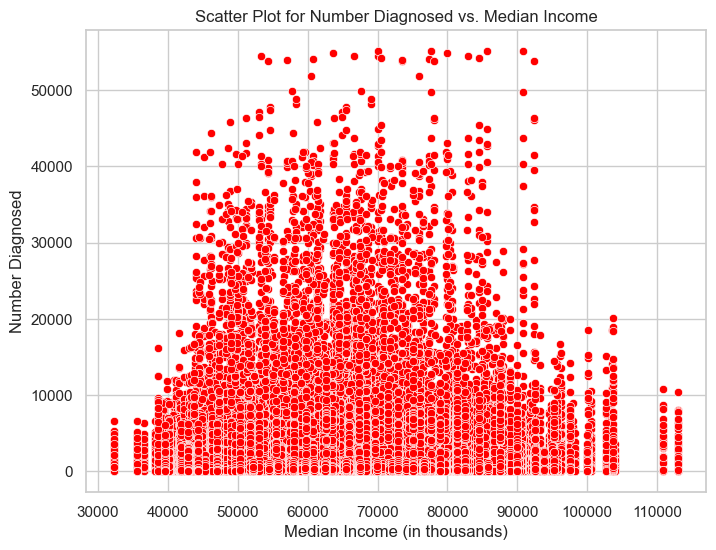

In [102]:
# Scatter plot showing number diagnosed against median income
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x='Median_Income', y='Number_Diagnosed', color='red')
plt.title("Scatter Plot for Number Diagnosed vs. Median Income")
plt.xlabel("Median Income (in thousands)")
plt.ylabel("Number Diagnosed")
plt.show()

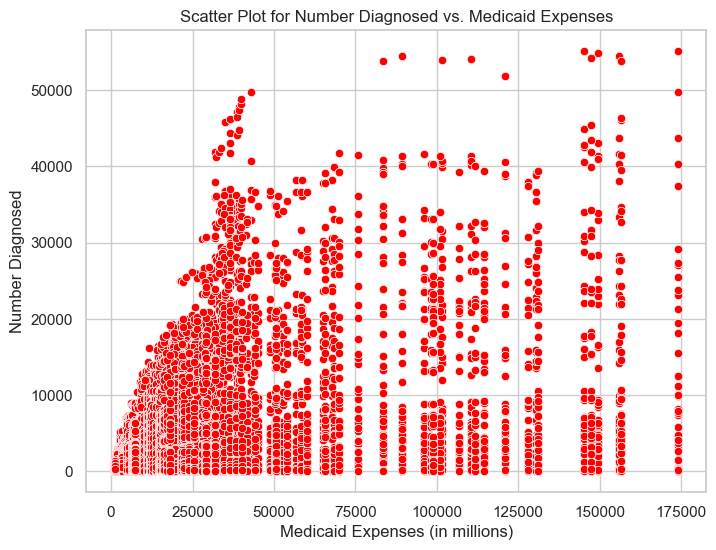

In [103]:
# Scatter plot showing number diagnosed against Medicaid expenses
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x='Medicaid_Expenses', y='Number_Diagnosed', color='red')
plt.title("Scatter Plot for Number Diagnosed vs. Medicaid Expenses")
plt.xlabel("Medicaid Expenses (in millions)")
plt.ylabel("Number Diagnosed")
plt.show()

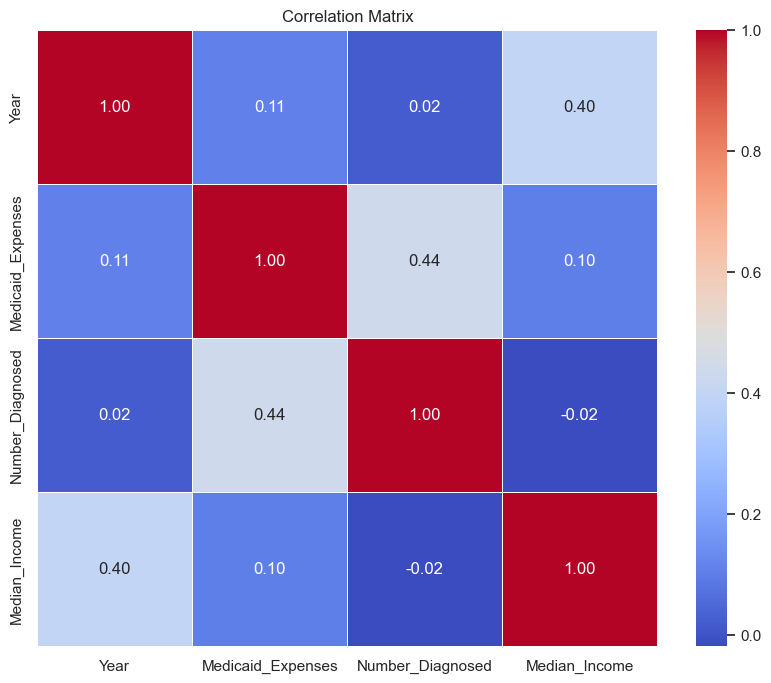

In [104]:
# Select only numeric columns
numeric_df = final_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
cor_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [105]:
X = final_df.drop(['Number_Diagnosed', 'Disease', 'StratificationCategory1'], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41278 entries, 0 to 41620
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   State_Name         41278 non-null  object
 1   Year               41278 non-null  int64 
 2   Medicaid_Expenses  41278 non-null  int64 
 3   Stratification1    41278 non-null  object
 4   Median_Income      41278 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 2.9+ MB


# Modeling

In [106]:
from sklearn.model_selection import train_test_split

# Set the seed for reproducibility
import numpy as np
np.random.seed(123)

# Assuming modified_df is your DataFrame
X = final_df.drop(['Number_Diagnosed', 'Disease', 'StratificationCategory1'], axis=1)  # Features (excluding the target)
X = pd.get_dummies(X, columns=['Stratification1', 'State_Name'], drop_first=False)
train_X = X[(X['Year'] >= 2010) & (X['Year'] <= 2018)]
test_X = X[(X['Year'] >= 2019) & (X['Year'] <= 2020)]
train_y = final_df[(final_df['Year'] >= 2010) & (final_df['Year'] <= 2018)]['Number_Diagnosed']  # Target variable
test_y = final_df[(final_df['Year'] >= 2019) & (final_df['Year'] <= 2020)]['Number_Diagnosed']

In [107]:
!pip install xgboost

In [108]:
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge


In [109]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(train_X, train_y)

# Ridge Regression (with alpha=1.0 as an example, you can tune this)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(train_X, train_y)

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_X, train_y)

# Gradient Boosting Regressor
gbm_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42)
gbm_model.fit(train_X, train_y)

# XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42)
xgb_model.fit(train_X, train_y)

# Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(train_X, train_y)

# Support Vector Regressor (SVM)
svm_model = SVR()
svm_model.fit(train_X, train_y)

# K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(train_X, train_y)

KNeighborsRegressor()

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
# Predict on test set
linear_pred = linear_model.predict(test_X)
ridge_pred = ridge_model.predict(test_X)
rf_pred = rf_model.predict(test_X)
gbm_pred = gbm_model.predict(test_X)
xgb_pred = xgb_model.predict(test_X)
dt_pred = dt_model.predict(test_X)
svm_pred = svm_model.predict(test_X)
knn_pred = knn_model.predict(test_X)

# Define a function to compute evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate each model
evaluate_model(test_y, linear_pred, "Linear Regression")
evaluate_model(test_y, ridge_pred, "Ridge Regression")
evaluate_model(test_y, rf_pred, "Random Forest Regressor")
evaluate_model(test_y, gbm_pred, "Gradient Boosting Regressor")
evaluate_model(test_y, xgb_pred, "XGBoost Regressor")
evaluate_model(test_y, dt_pred, "Decision Tree Regressor")
evaluate_model(test_y, svm_pred, "Support Vector Regressor")
evaluate_model(test_y, knn_pred, "K-Nearest Neighbors Regressor")


Linear Regression Performance:
MAE: 2760.1468
MSE: 18939816.6032
RMSE: 4351.9900
R² Score: 0.5349

Ridge Regression Performance:
MAE: 2761.2233
MSE: 18933022.4557
RMSE: 4351.2093
R² Score: 0.5351

Random Forest Regressor Performance:
MAE: 1679.6834
MSE: 10983147.5873
RMSE: 3314.0832
R² Score: 0.7303

Gradient Boosting Regressor Performance:
MAE: 2866.5886
MSE: 20825992.2136
RMSE: 4563.5504
R² Score: 0.4886

XGBoost Regressor Performance:
MAE: 2446.7467
MSE: 22044890.7788
RMSE: 4695.1987
R² Score: 0.4587

Decision Tree Regressor Performance:
MAE: 1700.1321
MSE: 11362756.7679
RMSE: 3370.8688
R² Score: 0.7210

Support Vector Regressor Performance:
MAE: 3308.8051
MSE: 44324506.8634
RMSE: 6657.6653
R² Score: -0.0885

K-Nearest Neighbors Regressor Performance:
MAE: 2037.3818
MSE: 14393050.5658
RMSE: 3793.8174
R² Score: 0.6466


Random Forest outperforms others in almost every metric. It explains ~73.5% of the variance (R²) and produces the smallest errors.

# Forecasting (2021-2050)

Step 1: Prepare the Data and Feature Selection

In [111]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Assuming final_df is your DataFrame

# Features (exclude target columns)
X = final_df.drop(['Number_Diagnosed', 'Disease', 'StratificationCategory1'], axis=1)

# One-hot encoding for categorical columns
X = pd.get_dummies(X, columns=['Stratification1', 'State_Name'], drop_first=False)

# Prepare the target variables for prediction
# Medicaid_Expenses and Median_Income
y_medicaid = final_df['Medicaid_Expenses']
y_income = final_df['Median_Income']

# Train-test split (we'll use the years from 2010 to 2020 for training, and 2021-2050 for prediction)
train_X = X[X['Year'] <= 2020]
test_X = X[X['Year'] > 2020]
train_y_medicaid = y_medicaid[X['Year'] <= 2020]
train_y_income = y_income[X['Year'] <= 2020]

Step 2: Train the Random Forest Models

In [112]:
# Initialize the Random Forest Regressors for Medicaid and Median Income
rf_model_medicaid = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_income = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models
rf_model_medicaid.fit(train_X, train_y_medicaid)
rf_model_income.fit(train_X, train_y_income)

RandomForestRegressor(random_state=42)

Step 3: Prepare Future Data for Prediction (2021-2050)

In [113]:
# Generate the years, states, and stratification values
years = np.arange(2021, 2051)
states = final_df['State_Name'].unique()
stratifications = final_df['Stratification1'].unique()

# Create the future DataFrame for predictions
future_df = pd.DataFrame([(state, year, strat)
                           for state in states
                           for year in years
                           for strat in stratifications],
                          columns=['State_Name', 'Year', 'Stratification1'])

# Add placeholder values for features (like Medicaid_Expenses and Median_Income)
future_df['Medicaid_Expenses'] = final_df['Medicaid_Expenses'].mean()
future_df['Median_Income'] = final_df['Median_Income'].mean()

# One-hot encoding for the categorical columns
future_X = pd.get_dummies(future_df, columns=['Stratification1', 'State_Name'], drop_first=False)

# View the first few rows of future data
print(future_df.head())

  State_Name  Year            Stratification1  Medicaid_Expenses  \
0    Alabama  2021                   Hispanic       20726.821212   
1    Alabama  2021                       Male       20726.821212   
2    Alabama  2021        White, non-Hispanic       20726.821212   
3    Alabama  2021                     Female       20726.821212   
4    Alabama  2021  Asian or Pacific Islander       20726.821212   

   Median_Income  
0   65354.266922  
1   65354.266922  
2   65354.266922  
3   65354.266922  
4   65354.266922  


Step 4: Predict Future Values for Medicaid and Median Income

In [114]:
# Predict Medicaid_Expenses and Median_Income for the future years (2021-2050)
future_df['Predicted_Medicaid_Expenses'] = rf_model_medicaid.predict(future_X)
future_df['Predicted_Median_Income'] = rf_model_income.predict(future_X)

# Use predicted Medicaid_Expenses and Median_Income in future_X
future_X['Medicaid_Expenses'] = future_df['Predicted_Medicaid_Expenses']
future_X['Median_Income'] = future_df['Predicted_Median_Income']

# Ensure future_X has the same columns as train_X
missing_cols = set(train_X.columns) - set(future_X.columns)
for col in missing_cols:
    future_X[col] = 0  # Add missing dummy columns with 0s

# Reorder columns to match training set
future_X = future_X[train_X.columns]

# Predict Number_Diagnosed using the trained Random Forest model
future_df['Predicted_Number_Diagnosed'] = rf_model.predict(future_X)

# Save the results to an Excel file
future_df.to_excel("predicted_number_diagnosed_2021_2050.xlsx", index=False)

print("Prediction saved to 'predicted_number_diagnosed_2021_2050.xlsx'")

Prediction saved to 'predicted_number_diagnosed_2021_2050.xlsx'


Step 5 : Save the Predictions to an Excel File